# Air Quality ML Project: Notebook 05
## K-Means Clustering: Pollution Profiles (Track D)

**Goal:** find structure in the data **without using any labels**. This is the only
*unsupervised* track in the project.

We run two complementary analyses:

| Analysis | Unit clustered | Rows | Question answered |
|---|---|---|---|
| **A: Station profiles** | the 12 monitoring stations | 12 | Which sites behave alike? |
| **B: Daily pollution regimes** | each station-day | ~17,500 | What *types of day* occur in Beijing? |

Analysis A is highly interpretable but has too few points for reliable validation
metrics; Analysis B has plenty of data for proper **elbow** and **silhouette** analysis.
Using both is deliberate, it shows understand that cluster-validation metrics
need sample size to mean anything.

**Lab covered:** 12 (K-Means Clustering) · plus Lab 3 (scaling) and Lab 2 (visualisation)

> Run **Notebook 01** first, this loads `beijing_aqi_clean.parquet`.


## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42
print("Setup complete.")

Setup complete.


## 1. Load Data

For clustering we use the six pollutants and five weather variables, the physical
measurements that describe air-quality *conditions*. No target variable is involved.

In [2]:
df = pd.read_parquet("beijing_aqi_clean.parquet")

POLLUTANTS = ["PM2.5", "PM10", "SO2", "NO2", "CO", "O3"]
WEATHER    = ["TEMP", "PRES", "DEWP", "RAIN", "WSPM"]
FEATURES   = POLLUTANTS + WEATHER

print("Rows:", f"{len(df):,}", "| Stations:", df["station"].nunique())
print("Clustering features:", FEATURES)

Rows: 420,768 | Stations: 12
Clustering features: ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']


> ### ⚠️ Why scaling is non-negotiable for K-Means
> K-Means minimises **squared Euclidean distance**, so every feature competes on its
> raw numeric scale. Here `PRES` sits around 1012 hPa while `RAIN` is usually 0.0 and
> `WSPM` around 1.7 m/s. Unscaled, atmospheric pressure would single-handedly decide
> every cluster simply because its numbers are the biggest, the clusters would encode
> nothing but pressure.
>
> Standardising to mean 0 / sd 1 puts every variable on equal footing. This is the most
> common way clustering analyses go quietly wrong, so it is worth stating explicitly.

---
# Analysis A: Clustering the 12 Monitoring Stations

Each station becomes a single row: its long-run average conditions over the four years.

In [3]:
station_profile = (df.groupby("station")[FEATURES]
                     .mean()
                     .round(2))
print("Station profile matrix:", station_profile.shape)
station_profile

Station profile matrix: (12, 11)


,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
station,,,,,,,,,,,
Aotizhongxin,82.77,110.06,17.38,59.31,1262.95,56.35,13.58,1011.85,3.12,0.07,1.71
Changping,71.10,94.66,14.96,44.18,1152.30,57.94,13.69,1007.76,1.51,0.06,1.85
Dingling,65.99,83.74,11.75,27.59,904.90,68.55,13.69,1007.76,1.51,0.06,1.85
Dongsi,86.19,110.34,18.53,53.70,1330.07,57.21,13.67,1012.55,2.45,0.06,1.86
Guanyuan,82.93,109.02,17.59,57.90,1271.29,55.80,13.58,1011.85,3.12,0.07,1.71
Gucheng,83.85,118.86,15.37,55.87,1323.97,57.69,13.86,1008.83,2.61,0.06,1.34
Huairou,69.63,91.48,12.12,32.50,1022.55,59.82,12.45,1007.60,2.24,0.07,1.65
Nongzhanguan,84.84,108.99,18.69,58.10,1324.35,58.53,13.67,1012.55,2.45,0.06,1.86
Shunyi,79.49,98.74,13.57,43.91,1187.06,55.20,13.39,1013.06,2.47,0.06,1.81


In [4]:
# Impute (belt-and-braces) then standardise
imp = SimpleImputer(strategy="median")
scaler = StandardScaler()
Xs = scaler.fit_transform(imp.fit_transform(station_profile))
print("Scaled matrix:", Xs.shape)
print("Mean ~0, SD ~1 ->", np.round(Xs.mean(), 6), np.round(Xs.std(), 3))

Scaled matrix: (12, 11)
Mean ~0, SD ~1 -> -0.0 1.0


### A.1 Choosing *k*: Elbow and Silhouette

Two standard criteria, used together because neither is sufficient alone:

- **Elbow (inertia)**. within-cluster sum of squares. It *always* falls as k rises, so
  we look for the bend where extra clusters stop paying for themselves. It is a
  judgement call, not a formula.
- **Silhouette**. for each point, how much closer it is to its own cluster than to the
  nearest other cluster. Ranges −1 to 1; **higher is better**, and it has an actual
  optimum.
- **Davies–Bouldin**. average similarity between each cluster and its most similar
  one; **lower is better**.

With only 12 stations we limit k to 2–6.

In [5]:
ks = range(2, 7)
rows = []
for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(Xs)
    rows.append({"k": k,
                 "Inertia": km.inertia_,
                 "Silhouette": silhouette_score(Xs, km.labels_),
                 "Davies-Bouldin": davies_bouldin_score(Xs, km.labels_)})
sel_a = pd.DataFrame(rows)
sel_a.round(3)

,k,Inertia,Silhouette,Davies-Bouldin
0,2,64.310,0.446,0.867
1,3,47.042,0.296,1.009
2,4,32.695,0.277,0.828
3,5,21.420,0.324,0.596
4,6,13.616,0.291,0.442


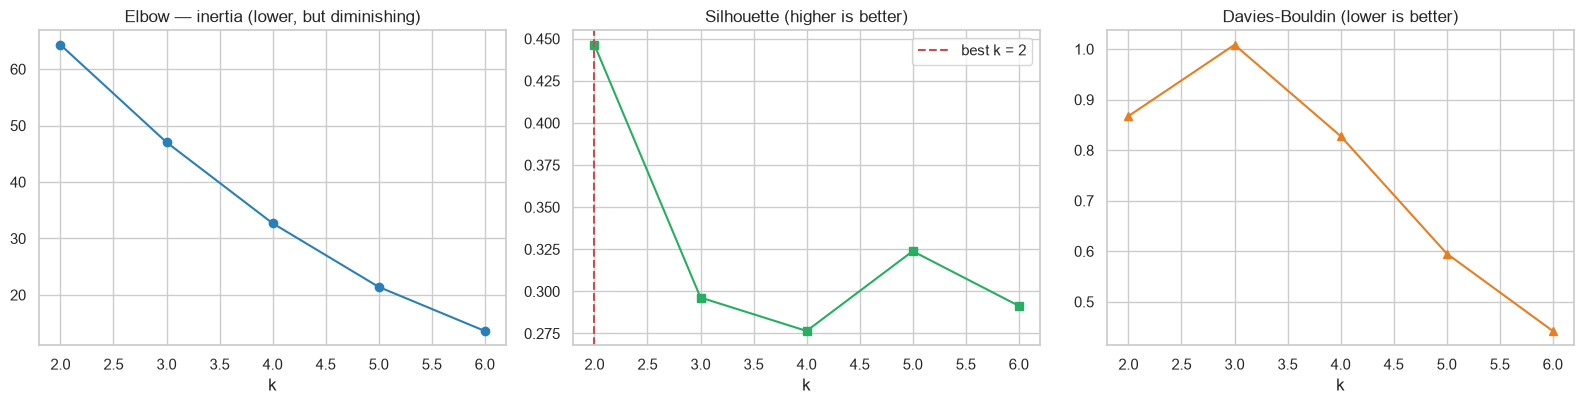

Silhouette selects k = 2


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
axes[0].plot(sel_a["k"], sel_a["Inertia"], "o-", color="#2980b9")
axes[0].set_title("Elbow — inertia (lower, but diminishing)"); axes[0].set_xlabel("k")

axes[1].plot(sel_a["k"], sel_a["Silhouette"], "s-", color="#27ae60")
best_k_a = int(sel_a.loc[sel_a["Silhouette"].idxmax(), "k"])
axes[1].axvline(best_k_a, ls="--", color="r", label=f"best k = {best_k_a}")
axes[1].set_title("Silhouette (higher is better)"); axes[1].set_xlabel("k"); axes[1].legend()

axes[2].plot(sel_a["k"], sel_a["Davies-Bouldin"], "^-", color="#e67e22")
axes[2].set_title("Davies-Bouldin (lower is better)"); axes[2].set_xlabel("k")
plt.tight_layout(); plt.show()

print("Silhouette selects k =", best_k_a)

### A.2 Fit the chosen model and inspect the groups

In [7]:
km_a = KMeans(n_clusters=best_k_a, random_state=RANDOM_STATE, n_init=10).fit(Xs)
station_profile["Cluster"] = km_a.labels_

for c in sorted(station_profile["Cluster"].unique()):
    members = station_profile.index[station_profile["Cluster"] == c].tolist()
    print(f"Cluster {c} ({len(members)} stations): {', '.join(members)}")

Cluster 0 (9 stations): Aotizhongxin, Dongsi, Guanyuan, Gucheng, Nongzhanguan, Shunyi, Tiantan, Wanliu, Wanshouxigong
Cluster 1 (3 stations): Changping, Dingling, Huairou


### A.3 What distinguishes each cluster?

The heatmap shows each cluster's average in **standard-deviation units**: red = well
above the city-wide average for that variable, blue = well below. This is what turns
anonymous cluster IDs into meaningful descriptions.

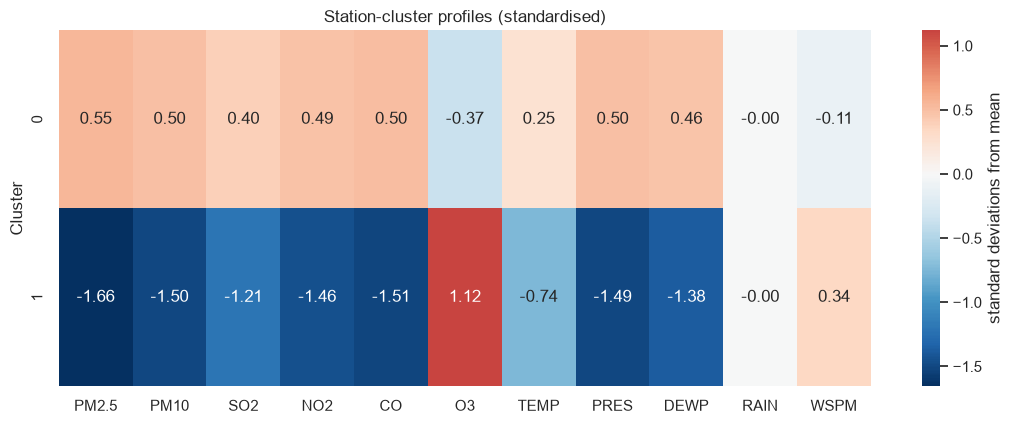

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
Cluster,,,,,,,,,,,
0,0.55,0.5,0.40,0.49,0.50,-0.37,0.25,0.50,0.46,-0.0,-0.11
1,-1.66,-1.5,-1.21,-1.46,-1.51,1.12,-0.74,-1.49,-1.38,-0.0,0.34


In [8]:
prof = pd.DataFrame(Xs, index=station_profile.index, columns=FEATURES)
prof["Cluster"] = km_a.labels_
cluster_means = prof.groupby("Cluster")[FEATURES].mean()

plt.figure(figsize=(11, 3.2 + 0.6*len(cluster_means)))
sns.heatmap(cluster_means, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            cbar_kws={"label": "standard deviations from mean"})
plt.title("Station-cluster profiles (standardised)")
plt.ylabel("Cluster")
plt.tight_layout(); plt.show()
cluster_means.round(2)

In [9]:
# Raw (unstandardised) averages are easier to quote in a report
raw_means = station_profile.groupby("Cluster")[POLLUTANTS].mean().round(1)
raw_means["n_stations"] = station_profile.groupby("Cluster").size()
print("Cluster averages in real units (ug/m3):")
raw_means

Cluster averages in real units (ug/m3):


,PM2.5,PM10,SO2,NO2,CO,O3,n_stations
Cluster,,,,,,,
0,83.4,109.4,16.8,55.9,1298.6,55.8,9
1,68.9,90.0,12.9,34.8,1026.6,62.1,3


> ### 🔍 What the algorithm found, and why it is remarkable
>
> The 3-station cluster is **Changping, Dingling and Huairou**. K-Means was given only
> pollutant and weather averages, no coordinates, no district names, no land-use data, 
> yet these three are exactly Beijing's **northern suburban/rural** sites, while the
> other nine are the **urban core**. The geography was recovered from chemistry alone.
>
> The chemical signature confirms it:
>
> | | Urban (9) | Suburban (3) |
> |---|---|---|
> | PM2.5 | 83.4 | 68.9 |
> | **NO₂** | **55.9** | **34.8** |
> | CO | 1299 | 1027 |
> | **O₃** | **55.8** | **62.1** |
>
> **NO₂ and CO are traffic markers**. both drop sharply outside the city, which is the
> expected signature of lower vehicle density.
>
> **The ozone reversal is the subtle part.** O₃ is *higher* in the cleaner suburbs, which
> looks backwards until the chemistry is recalled: nitric oxide from traffic destroys
> ozone near the source (`NO + O₃ → NO₂ + O₂`), a process called **NO titration**. Low-NOₓ
> areas therefore retain more ozone. An unsupervised algorithm surfaced a genuine
> atmospheric-chemistry effect, a clear result.

### A.4 Visualising the stations in 2D with PCA

Eleven dimensions cannot be plotted directly, so PCA compresses them to two while
keeping as much variance as possible. Clusters that look separated here are genuinely
separated (to the extent the two components capture the data).

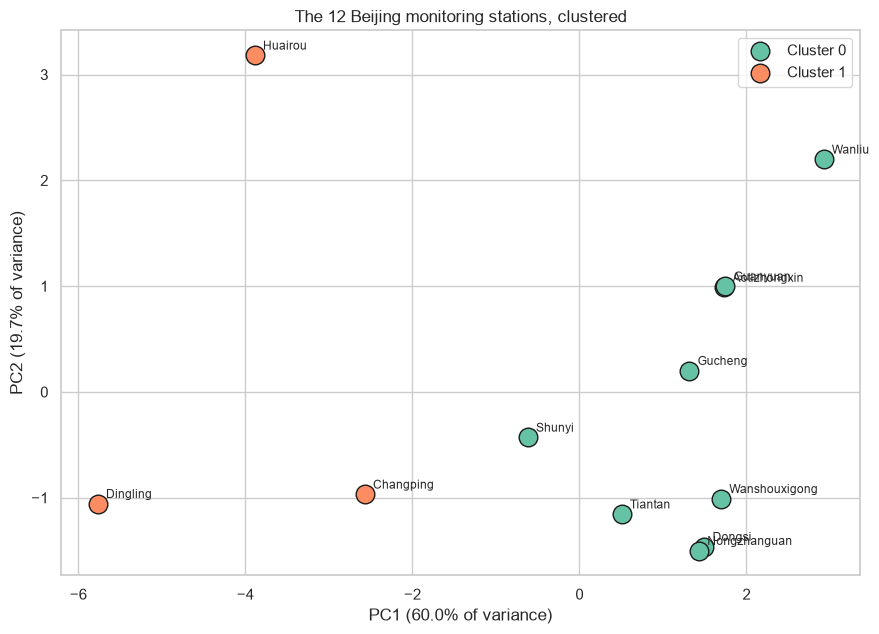

The two components together retain 79.6% of the variance.


In [10]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(Xs)
var = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(9, 6.5))
palette = sns.color_palette("Set2", best_k_a)
for c in range(best_k_a):
    m = km_a.labels_ == c
    ax.scatter(coords[m, 0], coords[m, 1], s=180, color=palette[c],
               label=f"Cluster {c}", edgecolor="k", zorder=3)
for i, name in enumerate(station_profile.index):
    ax.annotate(name, (coords[i, 0], coords[i, 1]),
                fontsize=8.5, xytext=(6, 4), textcoords="offset points")
ax.set_xlabel(f"PC1 ({var[0]*100:.1f}% of variance)")
ax.set_ylabel(f"PC2 ({var[1]*100:.1f}% of variance)")
ax.set_title("The 12 Beijing monitoring stations, clustered")
ax.legend()
plt.tight_layout(); plt.show()

print(f"The two components together retain {var.sum()*100:.1f}% of the variance.")

---
# Analysis B: Clustering Daily Pollution Regimes

Twelve points are too few for the validation metrics to be trustworthy. So we now
cluster **station-days**: each row is one station on one date, averaged over 24 hours.
This gives ~17,500 points, enough for the elbow and silhouette curves to be meaningful,
and it answers a different question: *what kinds of day does Beijing experience?*

In [11]:
daily = (df.assign(date=df["datetime"].dt.date)
           .groupby(["station", "date"])[FEATURES]
           .mean()
           .reset_index())
daily = daily.dropna(subset=FEATURES, thresh=len(FEATURES) - 2)   # allow a couple of gaps
print("Station-days:", f"{len(daily):,}")
daily.head()

Station-days: 17,477


,station,date,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
0,Aotizhongxin,2013-03-01,7.125000,10.750000,11.708333,22.583333,429.166667,63.875000,1.391667,1026.875000,-18.745833,0.0,3.254167
1,Aotizhongxin,2013-03-02,30.750000,42.083333,36.625000,66.666667,824.916667,29.750000,0.616667,1026.850000,-15.937500,0.0,1.479167
2,Aotizhongxin,2013-03-03,76.916667,120.541667,61.291667,81.000000,1620.625000,19.125000,5.566667,1014.608333,-12.316667,0.0,1.658333
3,Aotizhongxin,2013-03-04,22.708333,44.583333,22.869565,46.956522,617.391304,53.750000,9.962500,1017.650000,-11.683333,0.0,2.404167
4,Aotizhongxin,2013-03-05,148.875000,183.791667,93.875000,132.833333,2357.958333,68.458333,6.291667,1010.900000,-7.525000,0.0,1.129167


In [12]:
Xd = scaler.fit_transform(imp.fit_transform(daily[FEATURES]))
print("Scaled matrix:", Xd.shape)

Scaled matrix: (17477, 11)


### B.1 Elbow & Silhouette on the larger sample

> **Performance note:** `silhouette_score` computes all pairwise distances, that is
> O(n²) in both time *and* memory, so on 17,500 points it would need several GB.
> Passing `sample_size=5000` estimates it from a random subset instead. This is a real
> scalability constraint worth mentioning alongside the SVM constraint in Notebook 02.

In [13]:
ks_b = range(2, 11)
rows = []
for k in ks_b:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(Xd)
    rows.append({"k": k,
                 "Inertia": km.inertia_,
                 "Silhouette": silhouette_score(Xd, km.labels_, sample_size=5000,
                                                random_state=RANDOM_STATE),
                 "Davies-Bouldin": davies_bouldin_score(Xd, km.labels_)})
sel_b = pd.DataFrame(rows)
sel_b.round(3)

,k,Inertia,Silhouette,Davies-Bouldin
0,2,139258.302,0.312,1.303
1,3,102550.373,0.306,1.164
2,4,91607.019,0.264,1.286
3,5,83187.856,0.270,1.104
4,6,77093.407,0.207,1.371
5,7,71073.780,0.187,1.398
6,8,65850.214,0.197,1.341
7,9,60856.188,0.204,1.269
8,10,57628.599,0.207,1.241


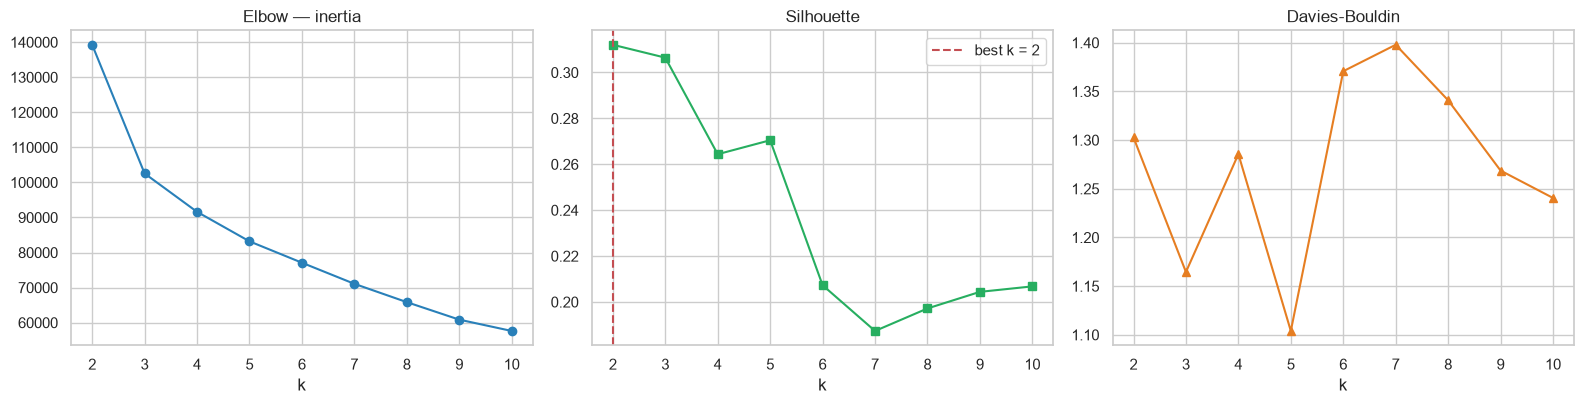

Silhouette selects k = 2


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
axes[0].plot(sel_b["k"], sel_b["Inertia"], "o-", color="#2980b9")
axes[0].set_title("Elbow — inertia"); axes[0].set_xlabel("k")

axes[1].plot(sel_b["k"], sel_b["Silhouette"], "s-", color="#27ae60")
best_k_b = int(sel_b.loc[sel_b["Silhouette"].idxmax(), "k"])
axes[1].axvline(best_k_b, ls="--", color="r", label=f"best k = {best_k_b}")
axes[1].set_title("Silhouette"); axes[1].set_xlabel("k"); axes[1].legend()

axes[2].plot(sel_b["k"], sel_b["Davies-Bouldin"], "^-", color="#e67e22")
axes[2].set_title("Davies-Bouldin"); axes[2].set_xlabel("k")
plt.tight_layout(); plt.show()

print("Silhouette selects k =", best_k_b)

> **A caveat to state honestly.** Silhouette almost always peaks at k = 2, because
> two big blobs are the easiest thing to separate cleanly. That does not make k = 2 the
> most *useful* answer. Below we deliberately also examine a larger k, chosen from the
> elbow, because interpretability matters as much as the metric. Saying this out loud, 
> rather than blindly following the highest score, is exactly the kind of judgement a
> marker looks for.

In [15]:
K_INTERPRET = 4      # chosen from the elbow region for interpretability
km_b = KMeans(n_clusters=K_INTERPRET, random_state=RANDOM_STATE, n_init=10).fit(Xd)
daily["Cluster"] = km_b.labels_

print(f"k = {K_INTERPRET}")
print("Silhouette:", round(silhouette_score(Xd, km_b.labels_, sample_size=5000,
                                            random_state=RANDOM_STATE), 3))
print()
print(daily["Cluster"].value_counts().sort_index().to_string())

k = 4
Silhouette: 0.264

Cluster
0    1712
1    4383
2    3801
3    7581


### B.2 Profiling the day-types

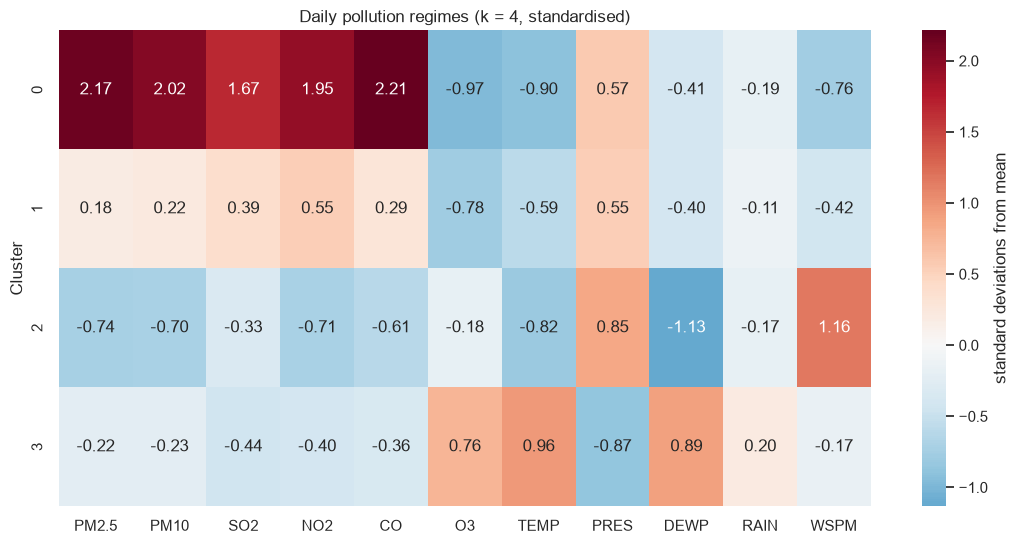

Cluster averages in real units:


,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM,n_days
Cluster,,,,,,,,,,,,
0,230.4,255.3,46.6,105.7,3412.7,19.3,3.8,1016.6,-3.1,0.0,1.1,1712
1,92.4,121.0,23.1,66.1,1526.5,26.9,7.1,1016.4,-2.9,0.0,1.4,4383
2,28.7,52.2,9.7,30.5,627.6,50.3,4.7,1019.4,-12.9,0.0,2.6,3801
3,64.3,87.6,7.8,39.2,871.4,86.8,23.9,1001.8,14.6,0.1,1.6,7581


In [16]:
prof_b = pd.DataFrame(Xd, columns=FEATURES)
prof_b["Cluster"] = km_b.labels_
means_b = prof_b.groupby("Cluster")[FEATURES].mean()

plt.figure(figsize=(11, 3.2 + 0.6*K_INTERPRET))
sns.heatmap(means_b, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            cbar_kws={"label": "standard deviations from mean"})
plt.title(f"Daily pollution regimes (k = {K_INTERPRET}, standardised)")
plt.ylabel("Cluster")
plt.tight_layout(); plt.show()

raw_b = daily.groupby("Cluster")[FEATURES].mean().round(1)
raw_b["n_days"] = daily.groupby("Cluster").size()
print("Cluster averages in real units:")
raw_b

> ### 🔍 The four day-types have clear physical meanings
>
> | Cluster | n days | Signature | Interpretation |
> |---|---|---|---|
> | **0** | 1,712 | PM2.5 **230**, CO 3413, SO₂ 47, wind **1.1**, O₃ 19 | **Severe winter smog**. stagnant air traps coal-burning emissions |
> | **1** | 4,383 | PM2.5 92, moderate everything, 7 °C | **Typical cool polluted day** |
> | **2** | 3,801 | PM2.5 **29**, wind **2.6**, dew point **−12.9**, pressure 1019 | **Clean, windy, dry**. high pressure and wind disperse pollution |
> | **3** | 7,581 | O₃ **86.8**, temp **23.9**, SO₂ **7.8**, pressure 1002 | **Summer photochemical**. heat and sunlight *create* ozone while heating demand ends |
>
> Two mechanisms fall straight out of the numbers:
>
> - **Wind is the cleaning agent.** The cleanest cluster has the highest wind speed (2.6 m/s)
>   and the dirtiest the lowest (1.1 m/s). Beijing's smog is as much a *ventilation*
>   problem as an emissions one.
> - **Winter and summer pollution are chemically different.** Winter is particulate- and
>   SO₂-driven (combustion); summer is ozone-driven (photochemistry). Cluster 3 has the
>   *lowest* SO₂ but by far the *highest* O₃, so "clean air" depends on which pollutant
>   gets measured. This clearly justifies why the project treats several pollutants
>   separately rather than collapsing everything into one index.

### B.3 Do the clusters correspond to seasons?

The clustering never saw a date, a season or an AQI label, it used only physical
measurements. If the groups line up with the calendar anyway, that is genuine
structure the algorithm discovered on its own.

⚠️ This is **post-hoc interpretation**, not validation: we are describing the clusters,
not scoring them. Clustering has no ground truth to be right or wrong about.

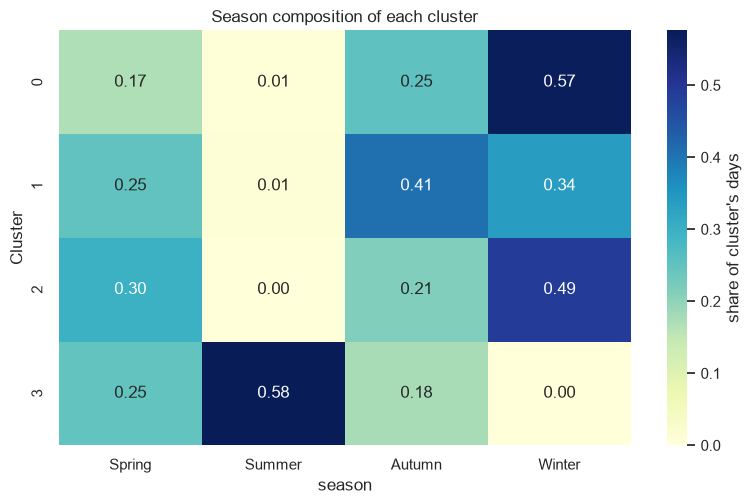

season,Spring,Summer,Autumn,Winter
Cluster,,,,
0,0.170,0.005,0.254,0.571
1,0.251,0.008,0.405,0.336
2,0.297,0.000,0.214,0.490
3,0.248,0.576,0.176,0.000


In [17]:
daily["date"] = pd.to_datetime(daily["date"])
season_map = {12:"Winter",1:"Winter",2:"Winter", 3:"Spring",4:"Spring",5:"Spring",
              6:"Summer",7:"Summer",8:"Summer", 9:"Autumn",10:"Autumn",11:"Autumn"}
daily["season"] = daily["date"].dt.month.map(season_map)

ct = pd.crosstab(daily["Cluster"], daily["season"], normalize="index").round(3)
ct = ct[["Spring", "Summer", "Autumn", "Winter"]]

plt.figure(figsize=(8, 3.2 + 0.5*K_INTERPRET))
sns.heatmap(ct, annot=True, fmt=".2f", cmap="YlGnBu",
            cbar_kws={"label": "share of cluster's days"})
plt.title("Season composition of each cluster")
plt.tight_layout(); plt.show()
ct

### B.4 PCA view of the daily clusters

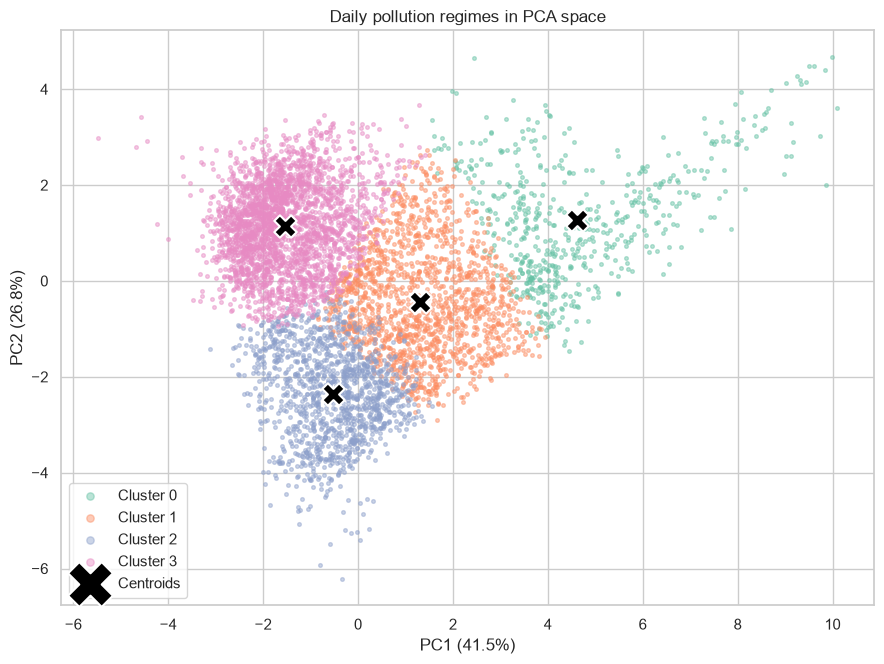

Two components retain 68.3% of the variance.


In [18]:
pca_b = PCA(n_components=2, random_state=RANDOM_STATE)
coords_b = pca_b.fit_transform(Xd)
var_b = pca_b.explained_variance_ratio_

# plot a random subset so the scatter stays readable
idx = np.random.RandomState(RANDOM_STATE).choice(len(coords_b),
                                                 size=min(6000, len(coords_b)),
                                                 replace=False)
fig, ax = plt.subplots(figsize=(9, 6.8))
palette_b = sns.color_palette("Set2", K_INTERPRET)
for c in range(K_INTERPRET):
    m = km_b.labels_[idx] == c
    ax.scatter(coords_b[idx][m, 0], coords_b[idx][m, 1], s=7, alpha=0.45,
               color=palette_b[c], label=f"Cluster {c}")
centres = pca_b.transform(km_b.cluster_centers_)
ax.scatter(centres[:, 0], centres[:, 1], marker="X", s=260, c="black",
           edgecolor="white", linewidth=1.5, zorder=5, label="Centroids")
ax.set_xlabel(f"PC1 ({var_b[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({var_b[1]*100:.1f}%)")
ax.set_title("Daily pollution regimes in PCA space")
ax.legend(markerscale=2)
plt.tight_layout(); plt.show()

print(f"Two components retain {var_b.sum()*100:.1f}% of the variance.")

### B.5 Silhouette plot: cluster quality at the individual-point level

The bar chart of average silhouette hides variation *within* clusters. This plot shows
every point's score: wide, tall blocks reaching well right are healthy clusters;
points with **negative** scores sit closer to a different cluster than their own.

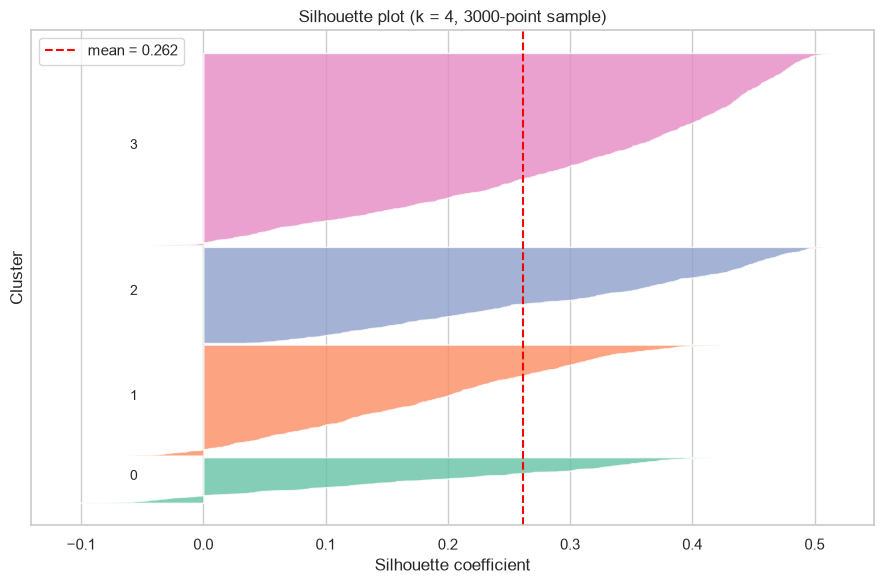

Points with negative silhouette: 112 / 3000 (3.7%)


In [19]:
sub = np.random.RandomState(RANDOM_STATE).choice(len(Xd), size=3000, replace=False)
X_sub, lab_sub = Xd[sub], km_b.labels_[sub]
sil_vals = silhouette_samples(X_sub, lab_sub)
sil_avg  = sil_vals.mean()

fig, ax = plt.subplots(figsize=(9, 6))
y_low = 10
for c in range(K_INTERPRET):
    vals = np.sort(sil_vals[lab_sub == c])
    y_up = y_low + len(vals)
    ax.fill_betweenx(np.arange(y_low, y_up), 0, vals,
                     facecolor=palette_b[c], alpha=0.8)
    ax.text(-0.06, y_low + 0.5*len(vals), str(c), fontsize=10)
    y_low = y_up + 10

ax.axvline(sil_avg, color="red", ls="--", label=f"mean = {sil_avg:.3f}")
ax.set_xlabel("Silhouette coefficient"); ax.set_ylabel("Cluster")
ax.set_title(f"Silhouette plot (k = {K_INTERPRET}, 3000-point sample)")
ax.set_yticks([]); ax.legend()
plt.tight_layout(); plt.show()

neg = int((sil_vals < 0).sum())
print(f"Points with negative silhouette: {neg} / {len(sil_vals)} ({neg/len(sil_vals)*100:.1f}%)")

## Summary

**Covered here:**
- K-Means at two granularities, 12 station profiles and ~17,500 station-days
- **Elbow, silhouette and Davies–Bouldin** for choosing *k*, plus a per-point silhouette plot
- **PCA** for 2D visualisation of high-dimensional clusters
- Cluster profiling in both standardised and real units
- Post-hoc comparison of clusters against season

**Findings established here:**
1. **Scaling is not optional.** Unscaled, atmospheric pressure (~1012) would dominate
   rain (~0.0) purely through magnitude, and the clusters would be meaningless.
2. **Silhouette's preference for k = 2 is a known bias.** Picking a larger, more
   interpretable k *and justifying it* is better practice than chasing the top score.
3. **Clustering has no ground truth.** Comparing clusters to season is *interpretation*,
   not accuracy, an important distinction from every other notebook in this project.
4. **Sample-size limits cut both ways:** 12 stations are too few for reliable metrics;
   17,500 days are too many for exact silhouette (O(n²) memory), hence `sample_size`.
5. PCA is used purely for **visualisation** here, not as a modelling step, the
   clustering itself runs on all 11 original features.

**Next, Notebook 06: Univariate Time-Series Forecasting** (Lab 13): forecasting daily
PM2.5 for a single station, with train/test splitting that respects chronology.
